In [ ]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import sys

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA is available: True


In [ ]:
!{sys.executable} -m pip install opencv-python matplotlib scikit-learn
!{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam3.git'

  Cloning https://github.com/facebookresearch/sam3.git to /tmp/pip-req-build-mra1eiei
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/sam3.git /tmp/pip-req-build-mra1eiei
  Resolved https://github.com/facebookresearch/sam3.git to commit f6e51f59500a87c576c2df2323ce56b9fd7a12de
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 106.3 MB/s eta 0:00:00
  Created wheel for sam3: filename=sam3-0.1.0-py3-none-any.whl size=1865952 sha256=a287423ba48c8863633fd8662513fc3dbb2c05cb00a56cd49ed0691f739e1990
  Stored in directory: /tmp/pip-ephem

In [ ]:
!pip install decord
!pip install --upgrade gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 125.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.1 MB/s eta 0:00:00


In [ ]:
!wget -O bpe_simple_vocab_16e6.txt.gz  https://huggingface.co/spaces/LanguageBind/LanguageBind/resolve/main/open_clip/bpe_simple_vocab_16e6.txt.gz?download=true

--2026-02-26 14:23:52--  https://huggingface.co/spaces/LanguageBind/LanguageBind/resolve/main/open_clip/bpe_simple_vocab_16e6.txt.gz?download=true
Resolving huggingface.co (huggingface.co)... 3.168.132.38, 3.168.132.91, 3.168.132.40, ...
Connecting to huggingface.co (huggingface.co)|3.168.132.38|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/651ce120942128c0919a8904/7fd381eaba73a2fb4c57602c2b86d89e89ad688f84220ab81da1c9bb14258159?response-content-disposition=attachment%3B+filename*%3DUTF-8%27%27bpe_simple_vocab_16e6.txt.gz%3B+filename%3D%22bpe_simple_vocab_16e6.txt.gz%22%3B&response-content-type=application%2Fgzip&Expires=1772119432&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiRXBvY2hUaW1lIjoxNzcyMTE5NDMyfX0sIlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjUxY2UxMjA5NDIxMjhjMDkxOWE4OTA0LzdmZDM4MWVhYmE3M2EyZmI0YzU3NjAyYzJiODZkODllODlhZDY4OGY4NDIyMGFiODFkYTFjOWJiMTQyNTgxNTlcX

In [ ]:
!cp /content/drive/MyDrive/Datasets/*.zip /content/

In [ ]:
import zipfile
import os

zip_dir = "/content/"

for filename in os.listdir(zip_dir):
    if filename.endswith(".zip"):
        folder_name = os.path.splitext(filename)[0]
        folder_path = os.path.join(zip_dir, folder_name)
        os.makedirs(folder_path, exist_ok=True)
        with zipfile.ZipFile(os.path.join(zip_dir, filename), 'r') as zip_ref:
            zip_ref.extractall(folder_path)
        print(f"Extracted: {filename} → {folder_path}")

for filename in os.listdir(zip_dir):
    if filename.endswith(".zip"):
        os.remove(os.path.join(zip_dir, filename))
        print(f"Deleted: {filename}")

Extracted: test.zip → /content/test
Extracted: train.zip → /content/train
Extracted: valid.zip → /content/valid
Deleted: test.zip
Deleted: train.zip
Deleted: valid.zip


In [ ]:
import os
import glob
import numpy as np
import torch
from PIL import Image
from tqdm import tqdm

import sam3
from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

In [ ]:
BPE_PATH = "/content/bpe_simple_vocab_16e6.txt.gz"
IMAGE_DIR = "/content/test"
LABEL_DIR = "/content/dataset/labels"
TEXT_PROMPT = "road and stairs and walkable area and sidewalk and floor"
CONFIDENCE_THRESHOLD = 0.4

os.makedirs(LABEL_DIR, exist_ok=True)

In [ ]:
model = build_sam3_image_model(bpe_path=BPE_PATH)
processor = Sam3Processor(model, confidence_threshold=CONFIDENCE_THRESHOLD)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

In [ ]:
def mask_to_yolo_polygon(mask, img_width, img_height, simplify_tolerance=2.0):
    import cv2
    mask_np = mask.squeeze().cpu().numpy().astype(np.uint8)
    contours, _ = cv2.findContours(mask_np, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    largest = max(contours, key=cv2.contourArea)

    epsilon = simplify_tolerance
    approx = cv2.approxPolyDP(largest, epsilon, True)

    if len(approx) < 3:
        return None

    points = approx.reshape(-1, 2)
    normalized = []
    for x, y in points:
        normalized.extend([x / img_width, y / img_height])

    return normalized

In [ ]:
image_paths = glob.glob(os.path.join(IMAGE_DIR, "*.jpg")) + \
              glob.glob(os.path.join(IMAGE_DIR, "*.jpeg")) + \
              glob.glob(os.path.join(IMAGE_DIR, "*.png"))

print(f"Found {len(image_paths)} images")

skipped = []
processed = []

for image_path in tqdm(image_paths):
    try:
        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        inference_state = processor.set_image(image)
        processor.reset_all_prompts(inference_state)
        inference_state = processor.set_text_prompt(state=inference_state, prompt=TEXT_PROMPT)

        masks = inference_state.get("masks")
        scores = inference_state.get("scores")

        if masks is None or masks.numel() == 0:
            skipped.append(image_path)
            continue

        stem = os.path.splitext(os.path.basename(image_path))[0]
        label_path = os.path.join(LABEL_DIR, stem + ".txt")

        lines = []
        for i in range(masks.shape[0]):
            mask = masks[i]
            polygon = mask_to_yolo_polygon(mask, width, height)
            if polygon is None:
                continue
            coords_str = " ".join(f"{v:.6f}" for v in polygon)
            lines.append(f"0 {coords_str}")

        if lines:
            with open(label_path, "w") as f:
                f.write("\n".join(lines))
            processed.append(image_path)
        else:
            skipped.append(image_path)

    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        skipped.append(image_path)

print(f"\nDone! Processed: {len(processed)}, Skipped: {len(skipped)}")
if skipped:
    print("Skipped files:", skipped)

Found 56 images


100%|██████████| 56/56 [03:27<00:00,  3.71s/it]


Done! Processed: 31, Skipped: 25
Skipped files: ['/content/test/gg_architecture_1d46c1729120d28c61962c43b7244351f0694210.jpg', '/content/test/gg_architecture_229eeca76791ed22d61c7a7fd87f5774de188942.jpg', '/content/test/gg_architecture_ec9515b70b20e6466d6332ab3277a979bdc48f4a.jpg', '/content/test/gg_architecture_2c35f23eaf15531f689958452d77eb07a7aac797.jpg', '/content/test/gg_architecture_5d4b31d5537fcf0ef589d2ae4c5323851b706ffe.jpg', '/content/test/gg_street_style_fashion_9916692052932336cb34b21b3a4942108c9b6b19.jpg', '/content/test/pin_architecture_b0f157298001a1baefcc3126c905acd1f42dd8b7.jpg', '/content/test/pin_architecture_ae222e64c2a12d464c2f61120535c827b1d3632a.jpg', '/content/test/pin_architecture_b3040f3b042d865d0da8ce25f926722b2e57a756.jpg', '/content/test/gg_architecture_d3f9b6d999c7d7b9ac1366ddfb3dc112493e8ebc.jpg', '/content/test/gg_architecture_5f2af6740abe86c223ffa40c07104dfb2983a766.jpg', '/content/test/pin_street_style_fashion_0e70106548e676cc452f73341a0253316fa6c1e2.

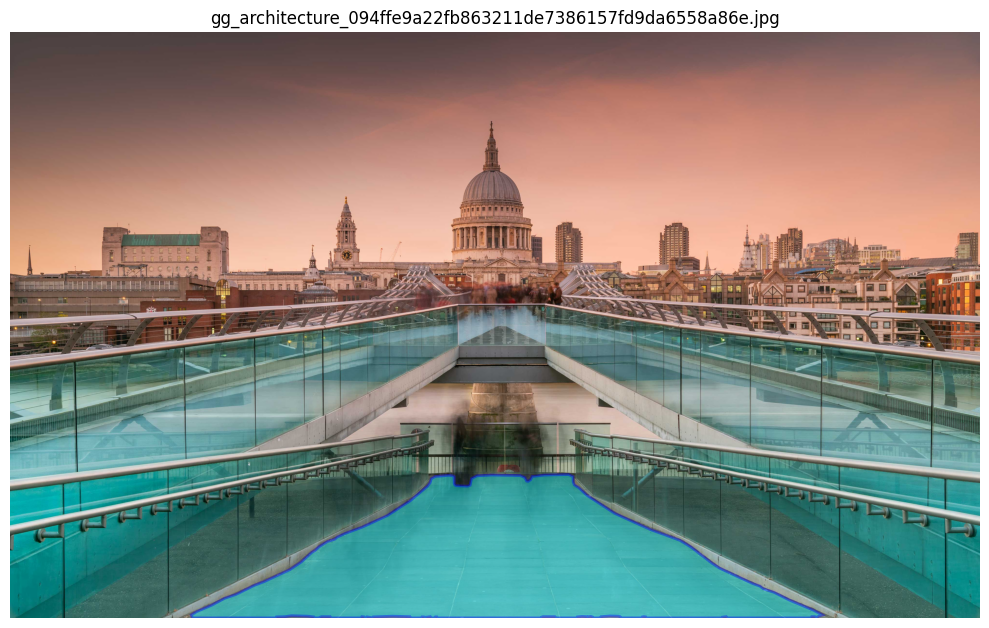

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

def visualize_label(image_path, label_path):
    img = Image.open(image_path)
    w, h = img.size

    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)

    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            cls = int(parts[0])
            coords = list(map(float, parts[1:]))
            points = np.array(coords).reshape(-1, 2)
            points[:, 0] *= w
            points[:, 1] *= h
            poly = Polygon(points, closed=True, fill=True,
                          facecolor='cyan', edgecolor='blue', alpha=0.4, linewidth=2)
            ax.add_patch(poly)

    ax.set_title(os.path.basename(image_path))
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if processed:
    sample = processed[0]
    stem = os.path.splitext(os.path.basename(sample))[0]
    label = os.path.join(LABEL_DIR, stem + ".txt")
    visualize_label(sample, label)

In [ ]:
!zip -r /content/test.zip /content/dataset/labels

  adding: content/dataset/labels/ (stored 0%)
  adding: content/dataset/labels/gg_architecture_81a17b105b03f23718f8edcdba48c1fd1796a8d4.txt (deflated 63%)
  adding: content/dataset/labels/pin_street_style_fashion_26fd207b1879586dd07d91045f5784c8c95cd39e.txt (deflated 70%)
  adding: content/dataset/labels/pin_architecture_90540a2df339d5a986a34913dd19a1c10d6490d0.txt (deflated 69%)
  adding: content/dataset/labels/pin_street_style_fashion_0793e2675c76a0b2e0c58fe080e47ef17b9aa150.txt (deflated 69%)
  adding: content/dataset/labels/gg_street_style_fashion_9f3bbdefc6b94b8f261a2558271988f6586c2652.txt (deflated 70%)
  adding: content/dataset/labels/pin_architecture_2390730dabd1566994eac93111bcc4eabf61ca82.txt (deflated 70%)
  adding: content/dataset/labels/gg_architecture_d6688f7066c79450b11ff4b87f971cb22f228ce6.txt (deflated 62%)
  adding: content/dataset/labels/pin_street_style_fashion_94c9c71bf76aa1a751e3c1d21b95f34ee75f5932.txt (deflated 63%)
  adding: content/dataset/labels/gg_architect

In [ ]:
!rm -rf /content/dataset